# Phase 1: Clustering-Oriented EDA

Credit-card transaction clustering.

## Research Question

Do credit-card transactions form natural density-distinct subpopulations, and do small clusters or anomalous observations meaningfully overlap fraudulent transactions?

In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image, display

ROOT = Path.cwd()
if ROOT.name == 'notebooks':
    ROOT = ROOT.parent

REPORT_DIR = ROOT / 'reports' / 'phase1'
FIGURE_DIR = ROOT / 'reports' / 'figures'
DATA_DIR = ROOT / 'data' / 'processed'

print('Project root:', ROOT)

Project root: /Users/nic/Desktop/Data-mining/credit-card-clustering


## Data Profile

In [2]:
profile = pd.read_csv(
    REPORT_DIR / 'clean_data_profile.csv'
)
profile

,column,dtype,n_rows,missing_count,missing_percent,unique_count,duplicate_count,minimum,maximum,mean,median,std,skewness
0,row_id,int64,283726,0,0.0,283726,0,0.000000,283725.000000,141862.500000,141862.500000,81904.785575,-8.670647e-16
1,Time,float64,283726,0,0.0,124592,159134,0.000000,172792.000000,94811.077600,84692.500000,47481.047891,-3.558065e-02
2,V1,float64,283726,0,0.0,275663,8063,-56.407510,2.454930,0.005917,0.020384,1.948026,-3.273271e+00
3,V2,float64,283726,0,0.0,275663,8063,-72.715728,22.057729,-0.004135,0.063949,1.646703,-4.695162e+00
4,V3,float64,283726,0,0.0,275663,8063,-48.325589,9.382558,0.001613,0.179963,1.508682,-2.151984e+00
5,V4,float64,283726,0,0.0,275663,8063,-5.683171,16.875344,-0.002966,-0.022248,1.414184,6.715042e-01
6,V5,float64,283726,0,0.0,275663,8063,-113.743307,34.801666,0.001828,-0.053468,1.377008,-2.414079e+00
7,V6,float64,283726,0,0.0,275663,8063,-26.160506,73.301626,-0.001139,-0.275168,1.331931,1.829880e+00
8,V7,float64,283726,0,0.0,275663,8063,-43.557242,120.589494,0.001801,0.040859,1.227664,2.890271e+00
9,V8,float64,283726,0,0.0,275663,8063,-73.216718,20.007208,-0.000854,0.021898,1.179054,-8.310970e+00


## Cleaning Decisions

In [3]:
with open(
    REPORT_DIR / 'cleaning_decision_log.json',
    encoding='utf-8',
) as file:
    cleaning_log = json.load(file)

cleaning_log

{'initial_rows': 284807,
 'final_rows': 283726,
 'initial_missing_cells': 0,
 'missing_by_column': {},
 'removed_rows_with_missing_or_malformed_values': 0,
 'initial_exact_duplicate_rows': 1081,
 'remove_exact_duplicates': True,
 'removed_exact_duplicates': 1081,
 'removed_negative_amount_rows': 0,
 'removed_negative_time_rows': 0,
 'removed_invalid_class_rows': 0,
 'sorting': 'Ascending by Time using stable sort.',
 'label_policy': 'Class is retained only for external evaluation and is never included in scaling, PCA, UMAP fitting, Hopkins, VAT, or clustering input.',
 'missing_value_policy': 'No arbitrary imputation is used. Malformed/missing records are removed and counted because artificial fills can create spurious distance structure.',
 'duplicate_policy': 'Exact duplicates are removed when enabled because duplicate records artificially inflate local density. A later sensitivity analysis should also rerun the final clustering without duplicate removal.',
 'genuine_outlier_policy':

## Extended EDA Summary

In [4]:
eda_summary = pd.read_csv(
    REPORT_DIR / 'extended_eda_summary.csv'
)
eda_summary

,Unnamed: 0,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max,skewness,kurtosis,iqr
0,V1,283726.0,0.005917,1.948026,-56.407510,-6.498966,-2.881365,-0.915951,0.020384,1.316068,2.081438,2.237325,2.454930,-3.273271,32.727332,2.232019
1,V2,283726.0,-0.004135,1.646703,-72.715728,-4.960666,-1.973354,-0.600321,0.063949,0.800283,1.796086,3.766340,22.057729,-4.695162,96.898173,1.400603
2,V3,283726.0,0.001613,1.508682,-48.325589,-3.950781,-2.386035,-0.889682,0.179963,1.026960,2.062083,2.725875,9.382558,-2.151984,25.186530,1.916642
3,V4,283726.0,-0.002966,1.414184,-5.683171,-3.124264,-2.198094,-0.850134,-0.022248,0.739647,2.556595,4.244400,16.875344,0.671504,2.618780,1.589781
4,V10,283726.0,-0.001441,1.076407,-24.588262,-2.091204,-1.338367,-0.535578,-0.093237,0.453619,1.546176,3.190847,23.745136,1.252967,29.843899,0.989197
5,V14,283726.0,0.000252,0.952215,-19.214325,-2.782010,-1.437213,-0.425732,0.050209,0.492336,1.391957,2.146224,10.526766,-1.918804,23.041488,0.918068
6,V17,283726.0,0.000170,0.842507,-25.162799,-1.347199,-0.982773,-0.483928,-0.065867,0.398972,1.272544,2.285339,9.253526,-3.690497,93.323101,0.882899
7,Amount_log1p,283726.0,3.153760,1.657080,0.000000,0.113329,0.652325,1.887070,3.135494,4.363226,5.903555,6.927524,10.153941,0.161410,-0.641333,2.476156


## Scaling Comparison

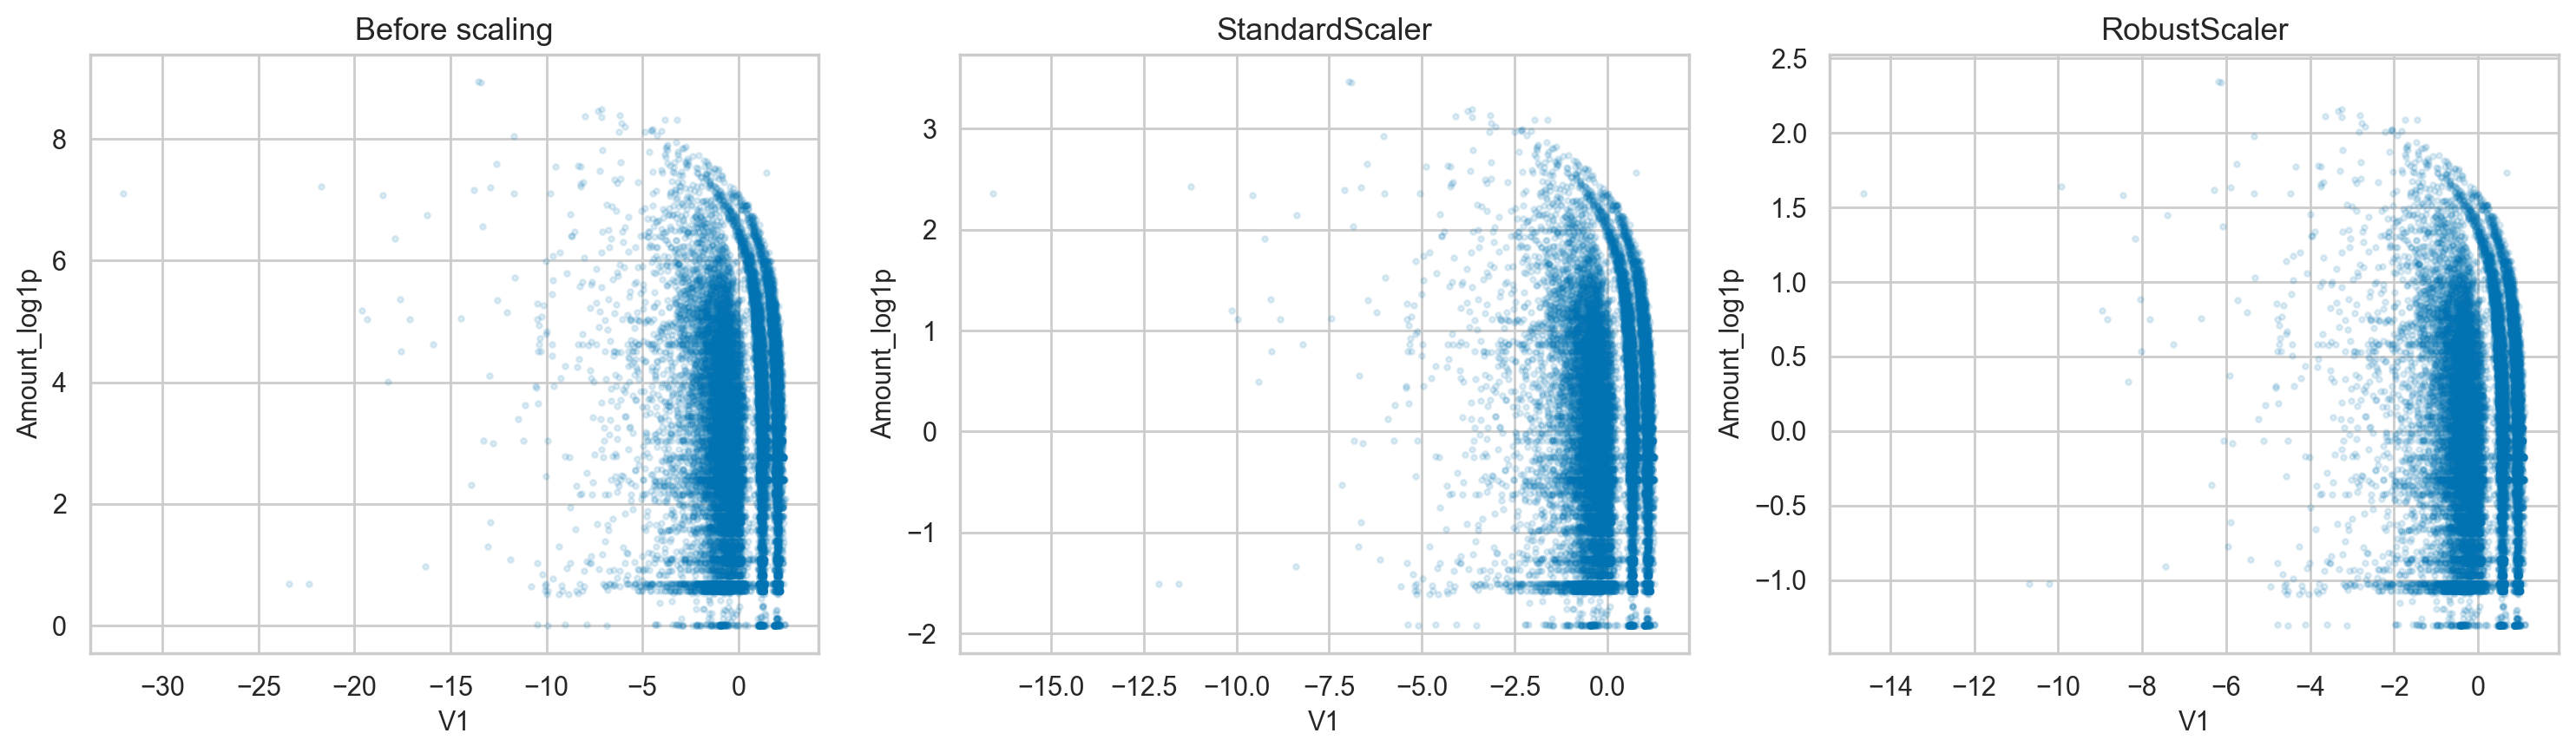

In [5]:
display(Image(
    filename=str(
        FIGURE_DIR / 'phase1_scaling_before_after.png'
    )
))

## PCA Explained Variance

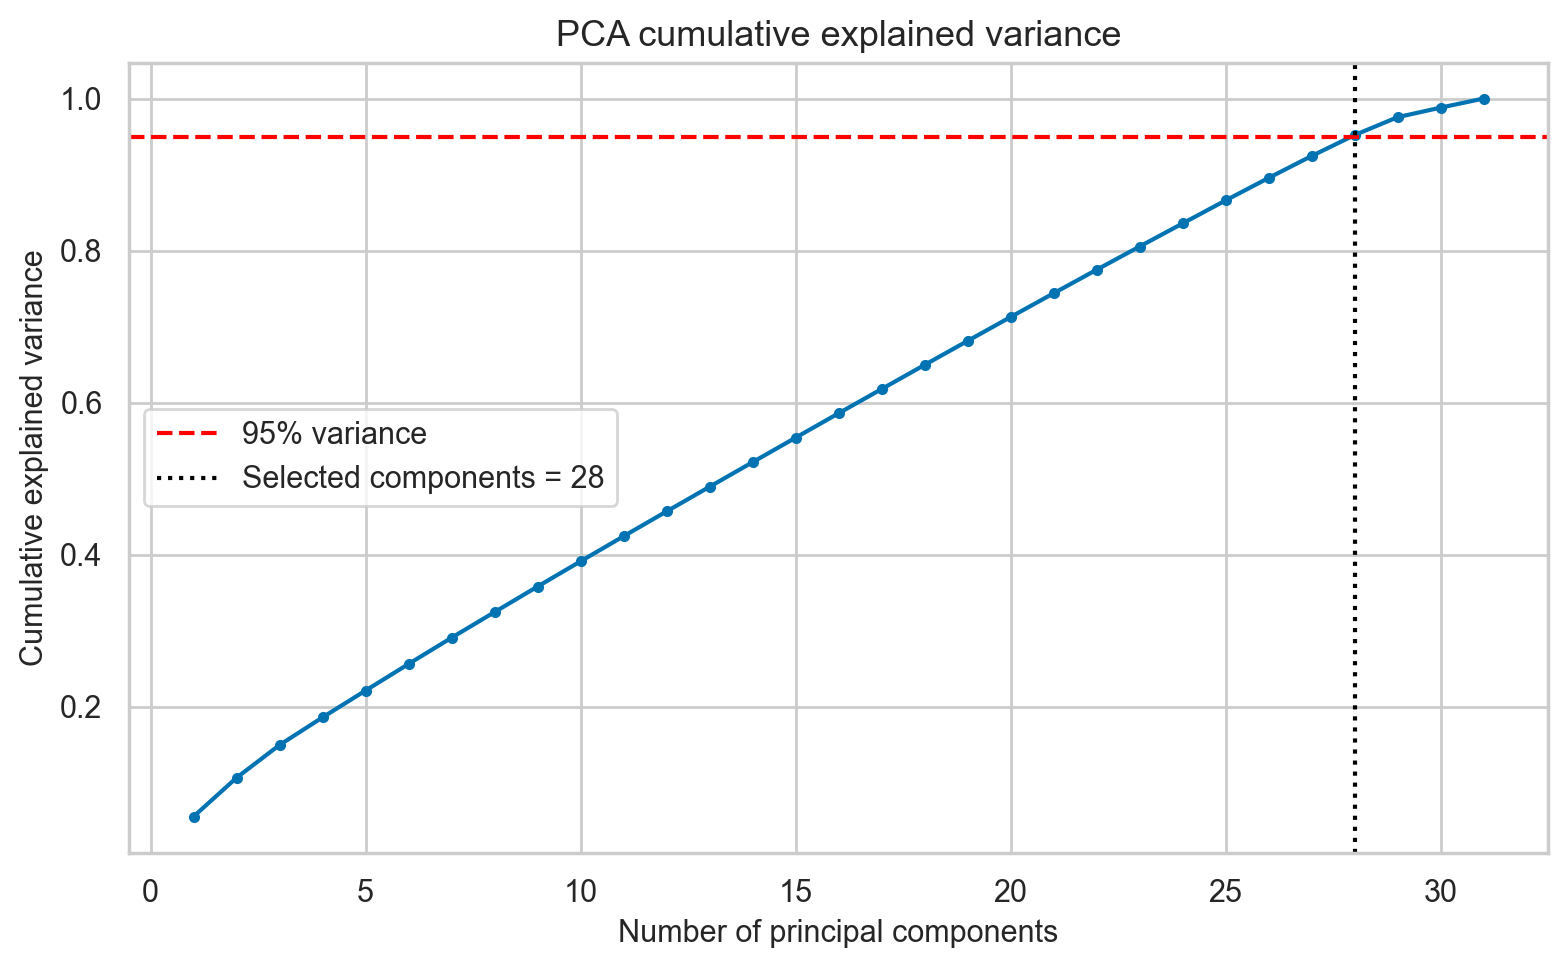

In [6]:
display(Image(
    filename=str(
        FIGURE_DIR / 'phase1_pca_explained_variance.png'
    )
))

## PCA Density Projection

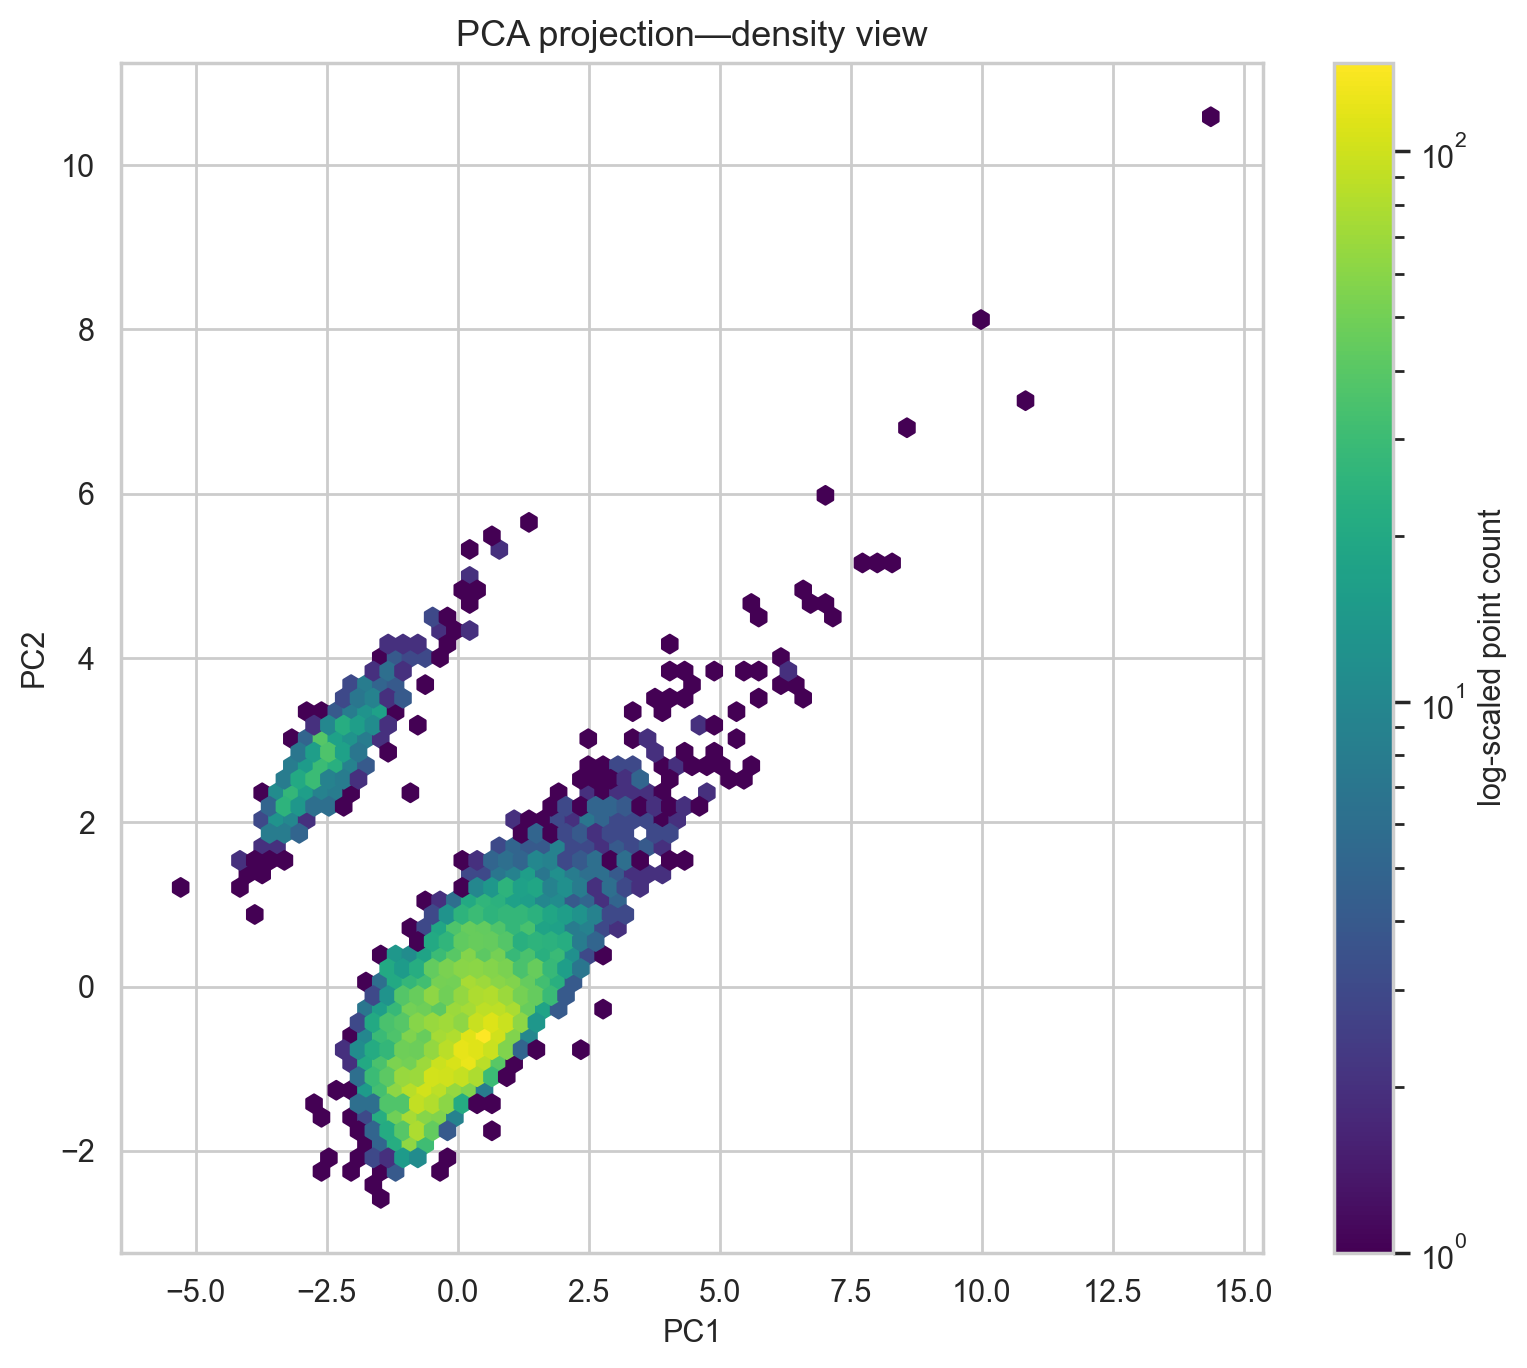

In [7]:
display(Image(
    filename=str(
        FIGURE_DIR / 'phase1_pca_density.png'
    )
))

## UMAP Density Projection

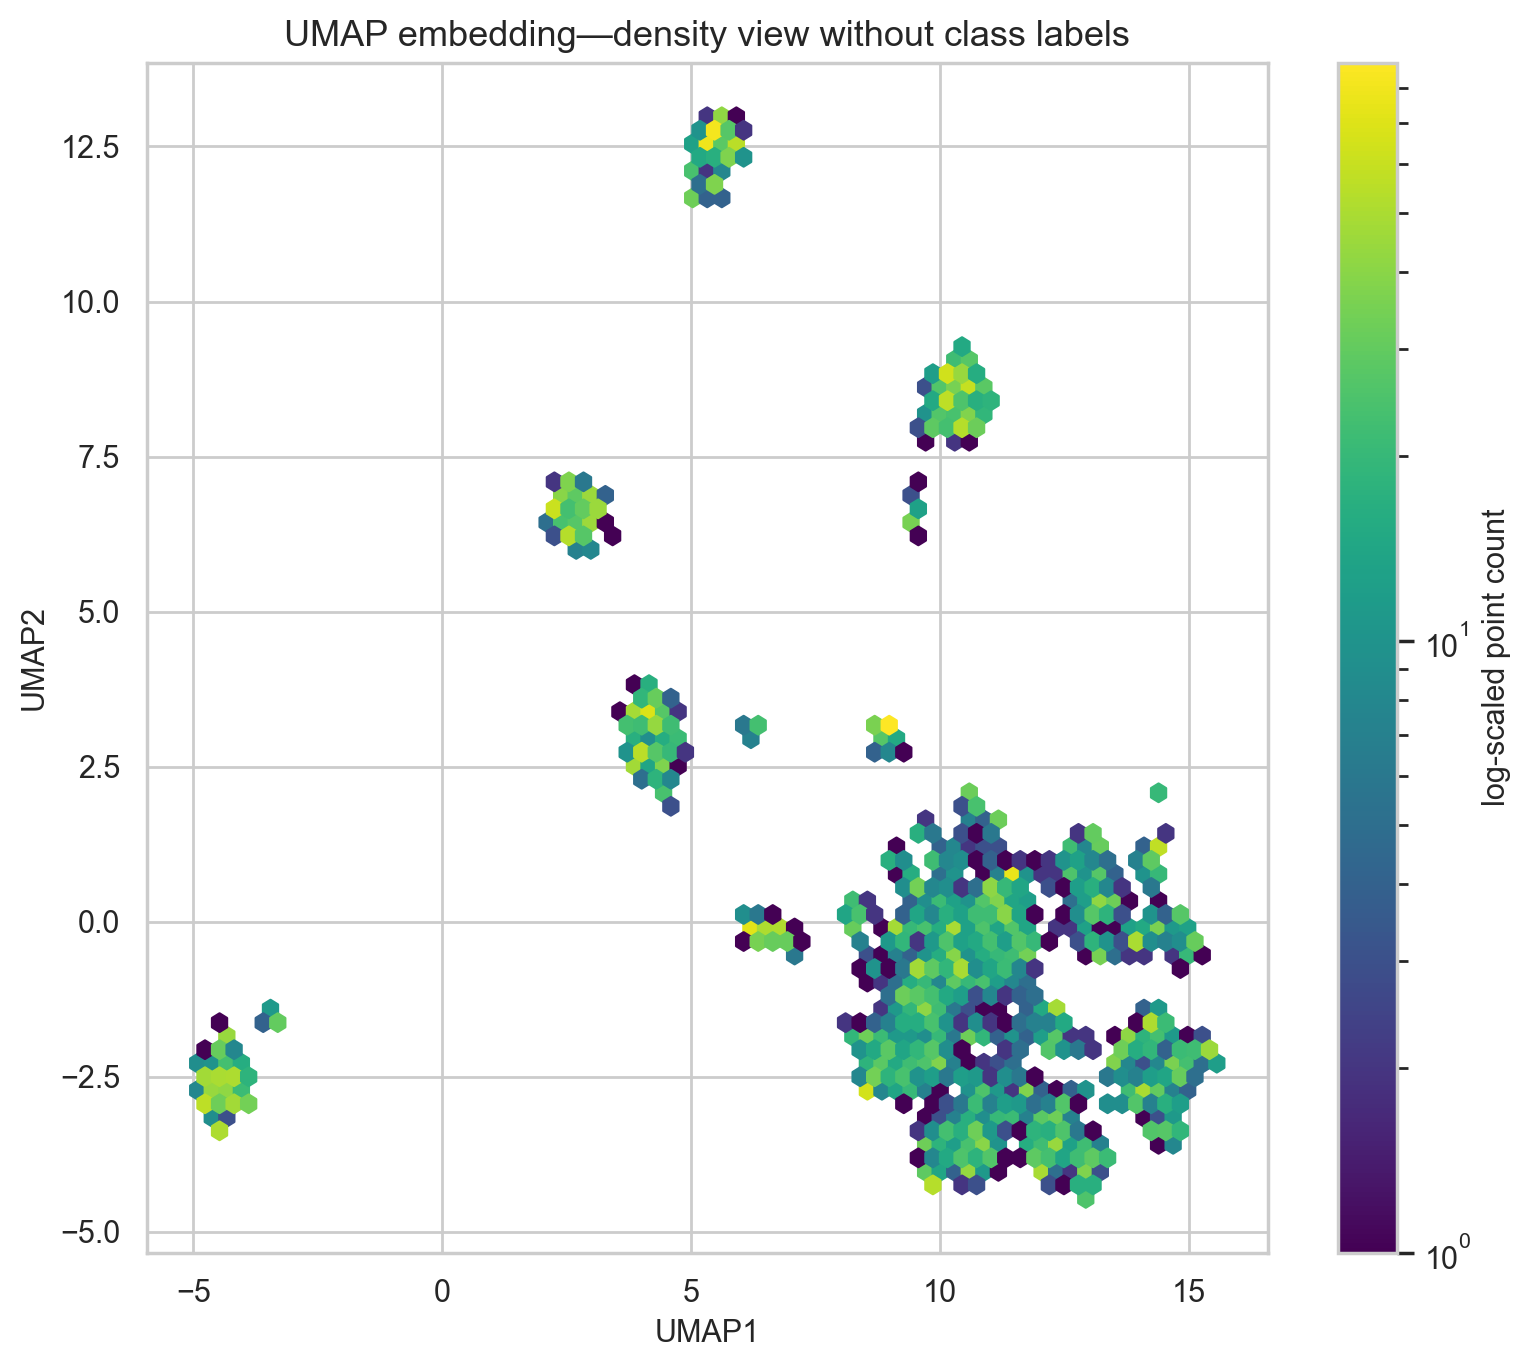

In [8]:
display(Image(
    filename=str(
        FIGURE_DIR / 'phase1_umap_density.png'
    )
))

## Hopkins Statistic

In [9]:
hopkins = pd.read_csv(
    REPORT_DIR / 'hopkins_results.csv'
)

hopkins.groupby('scaler')['hopkins'].agg(
    ['mean', 'std', 'min', 'max']
)

,mean,std,min,max
scaler,,,,
robust,0.999999,0.000001,0.999997,1.0
standard,0.999957,0.000096,0.999785,1.0


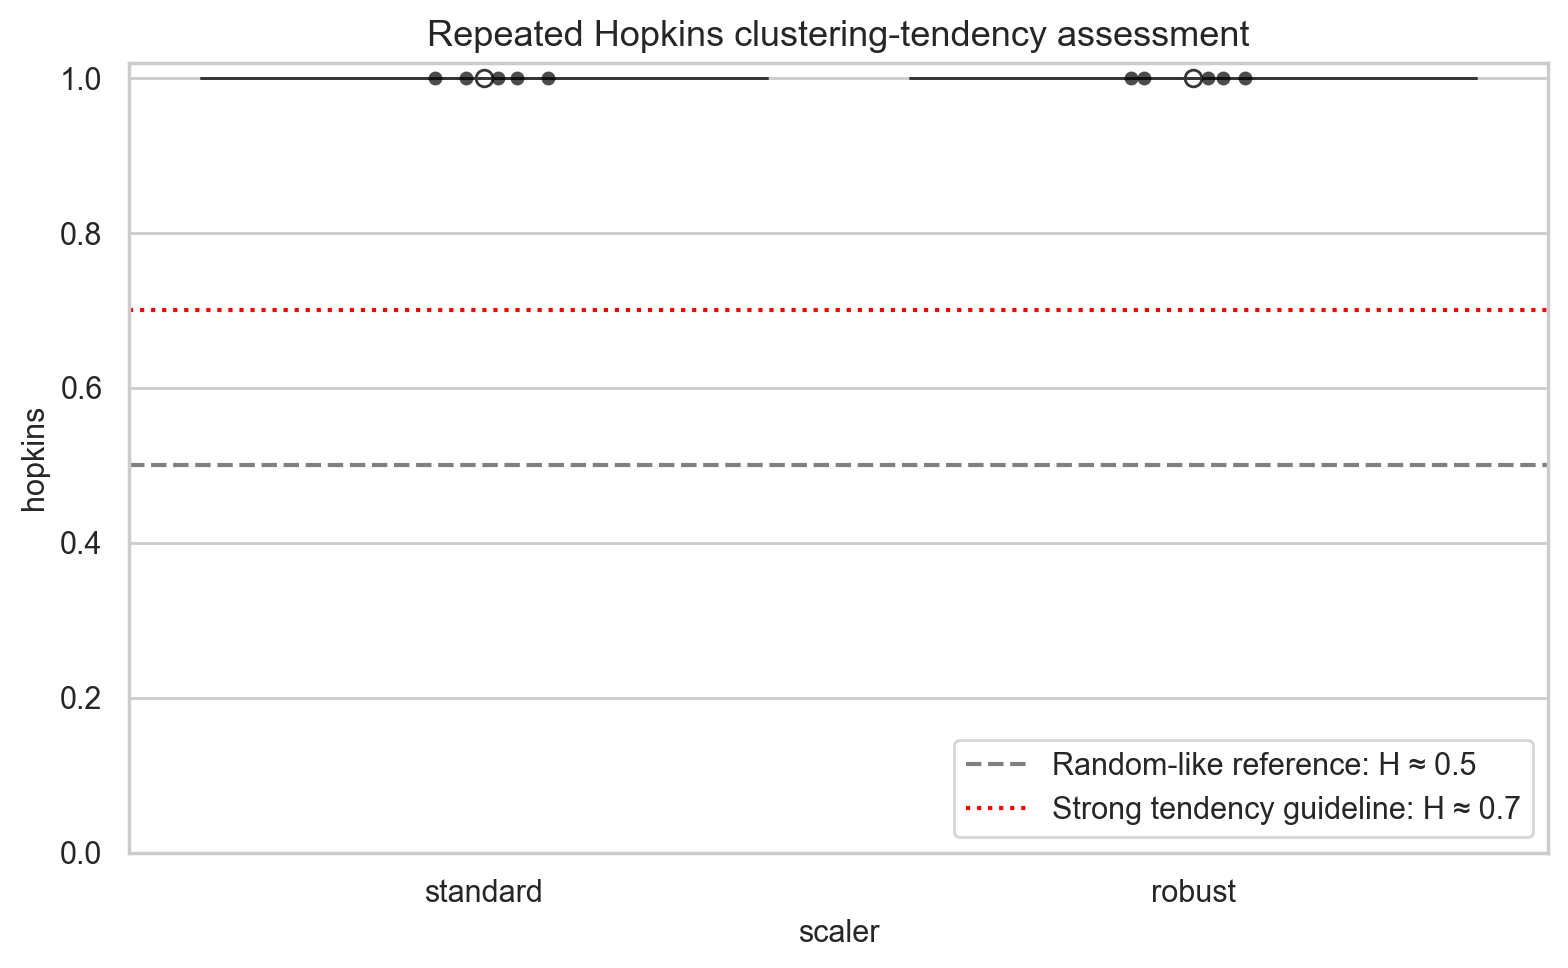

In [10]:
display(Image(
    filename=str(
        FIGURE_DIR / 'phase1_hopkins_results.png'
    )
))

## MST-Based VAT

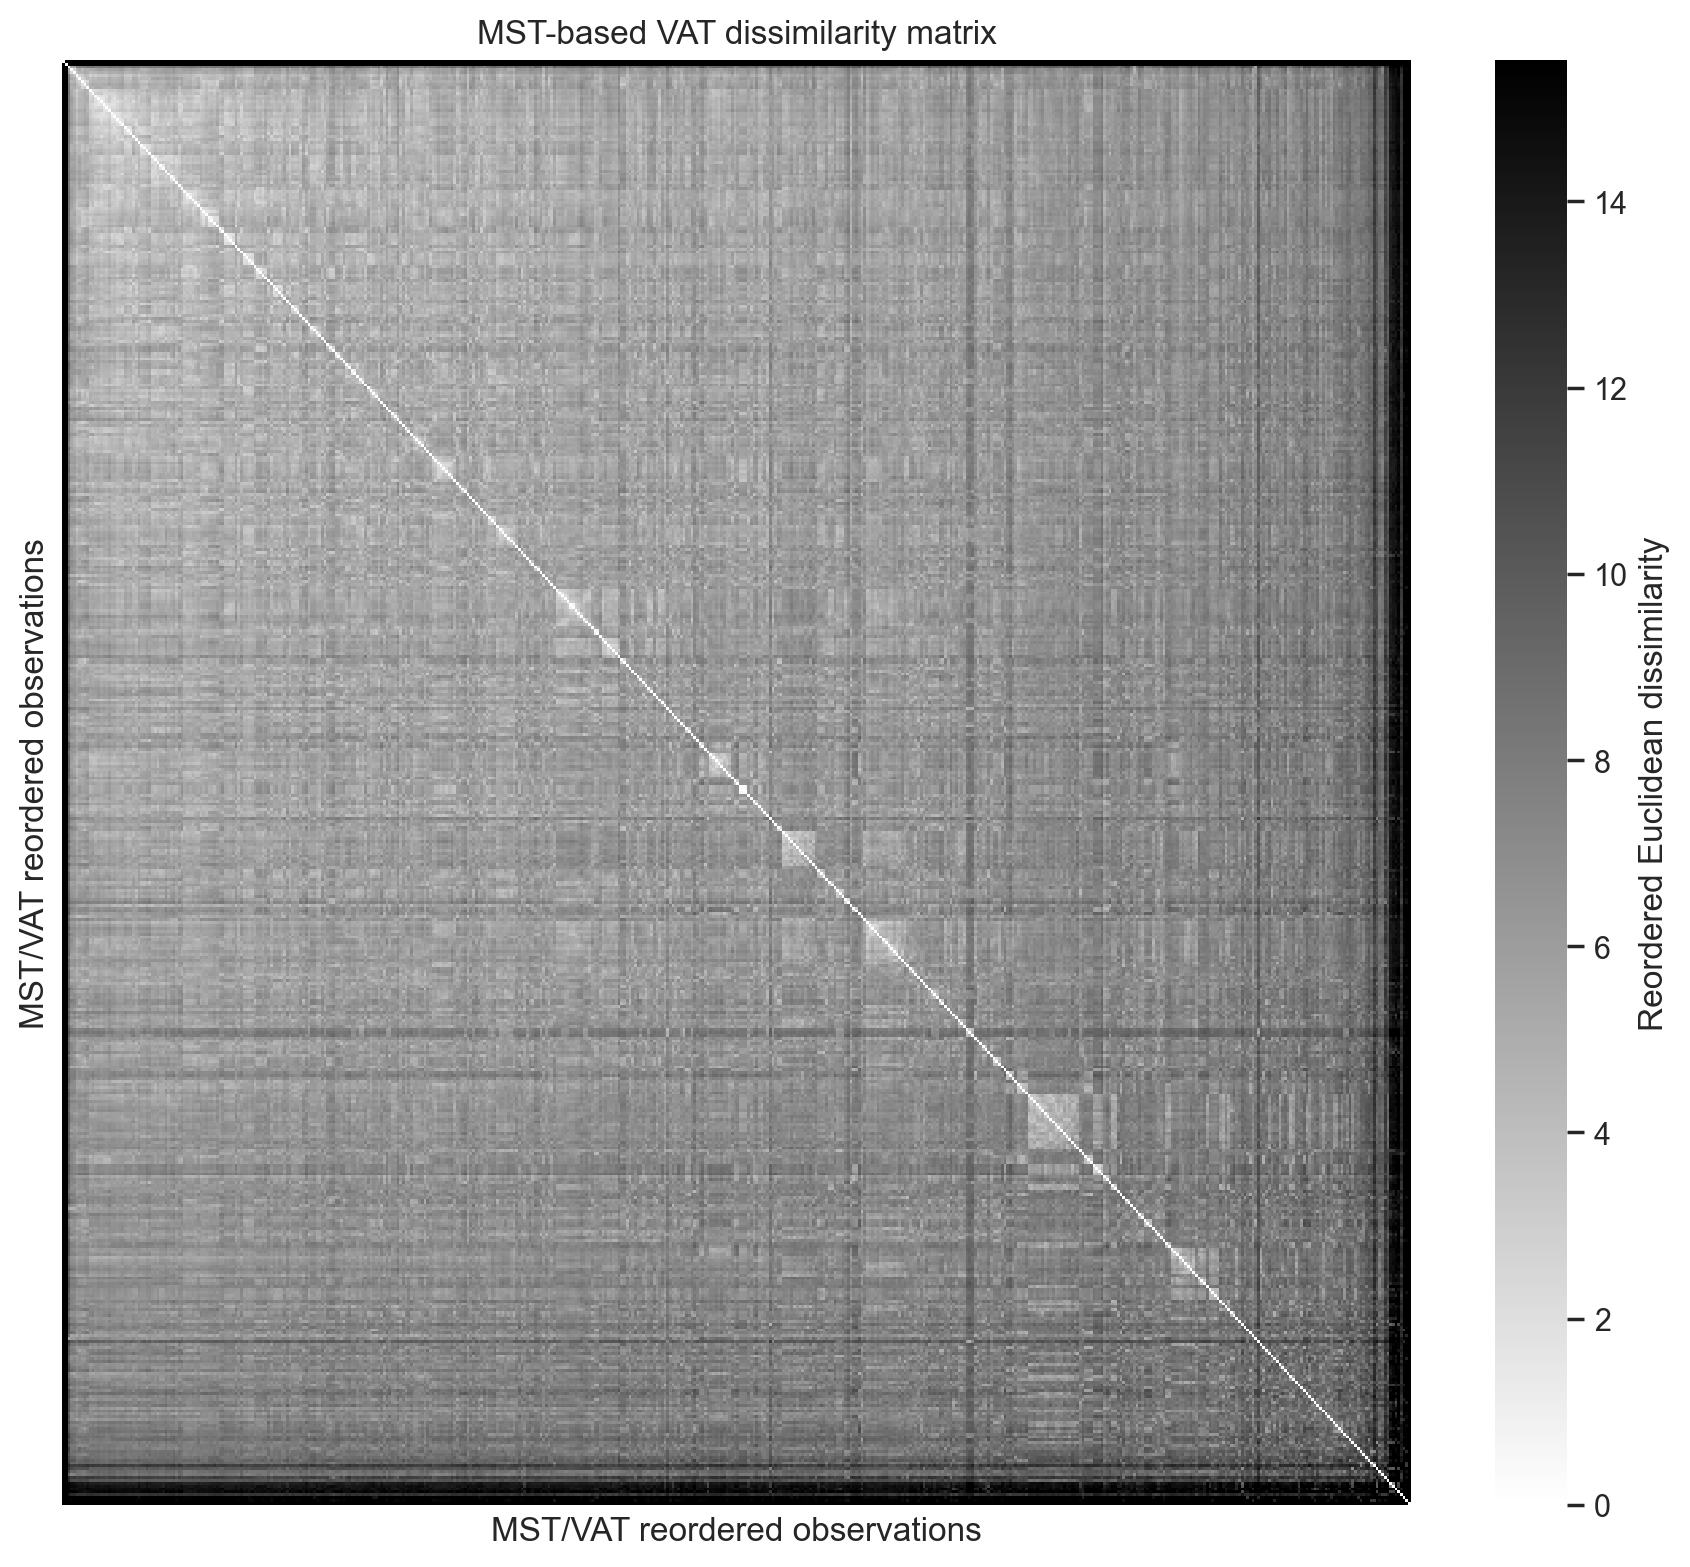

In [11]:
display(Image(
    filename=str(
        FIGURE_DIR / 'phase1_vat_mst_heatmap.png'
    )
))

## Box Plots

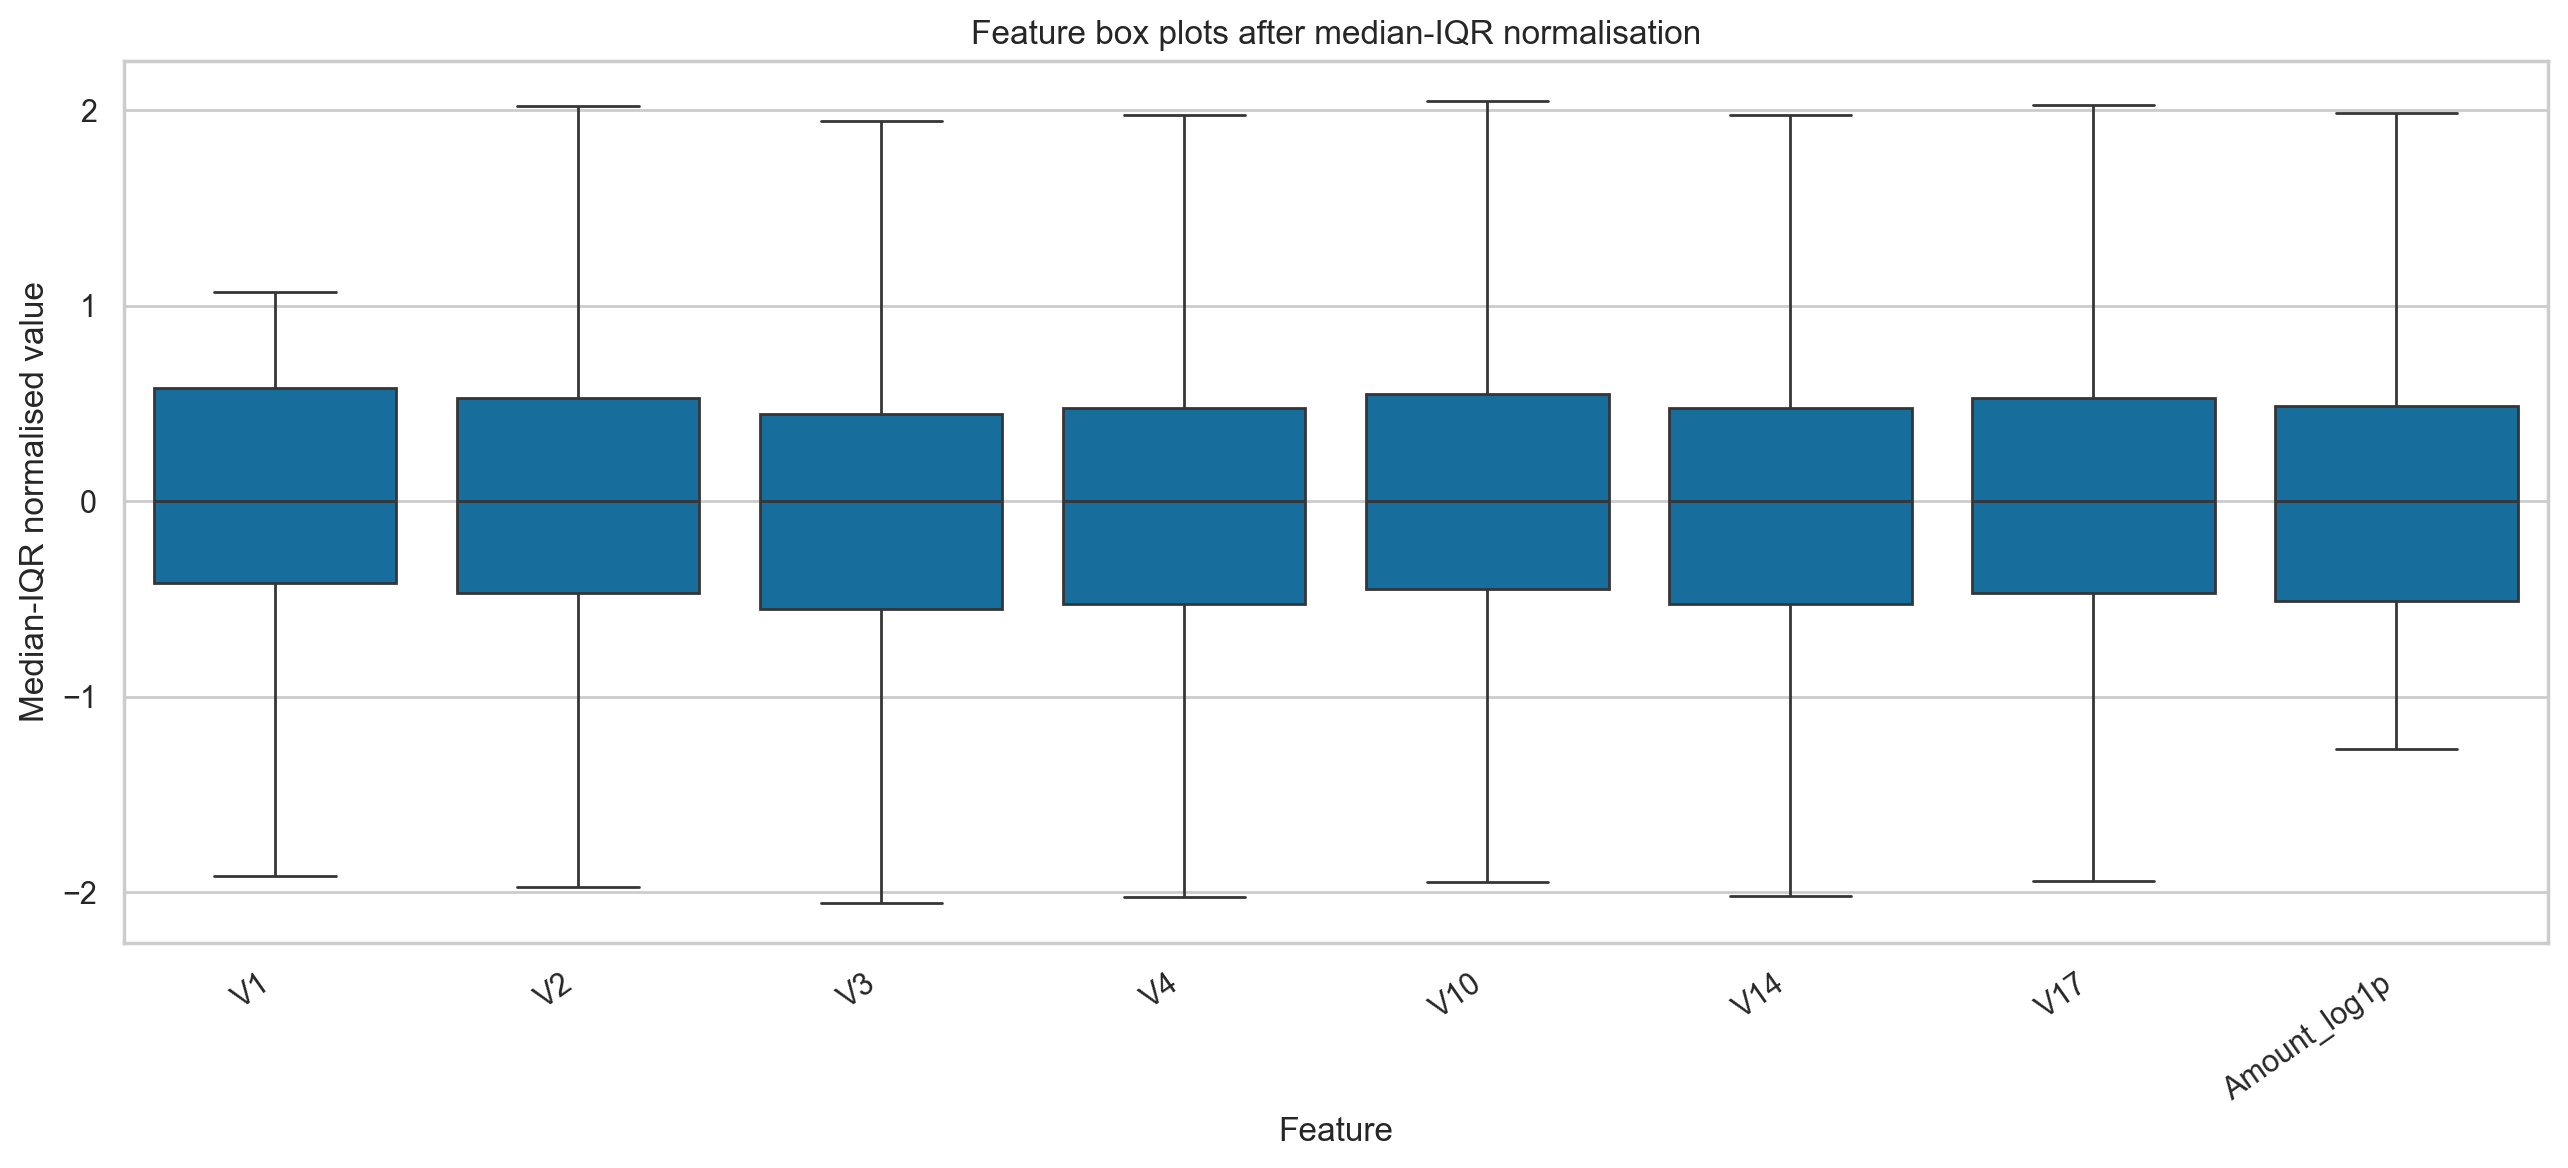

In [12]:
display(Image(
    filename=str(
        FIGURE_DIR / 'phase1_feature_boxplots.png'
    )
))

## QQ Plots

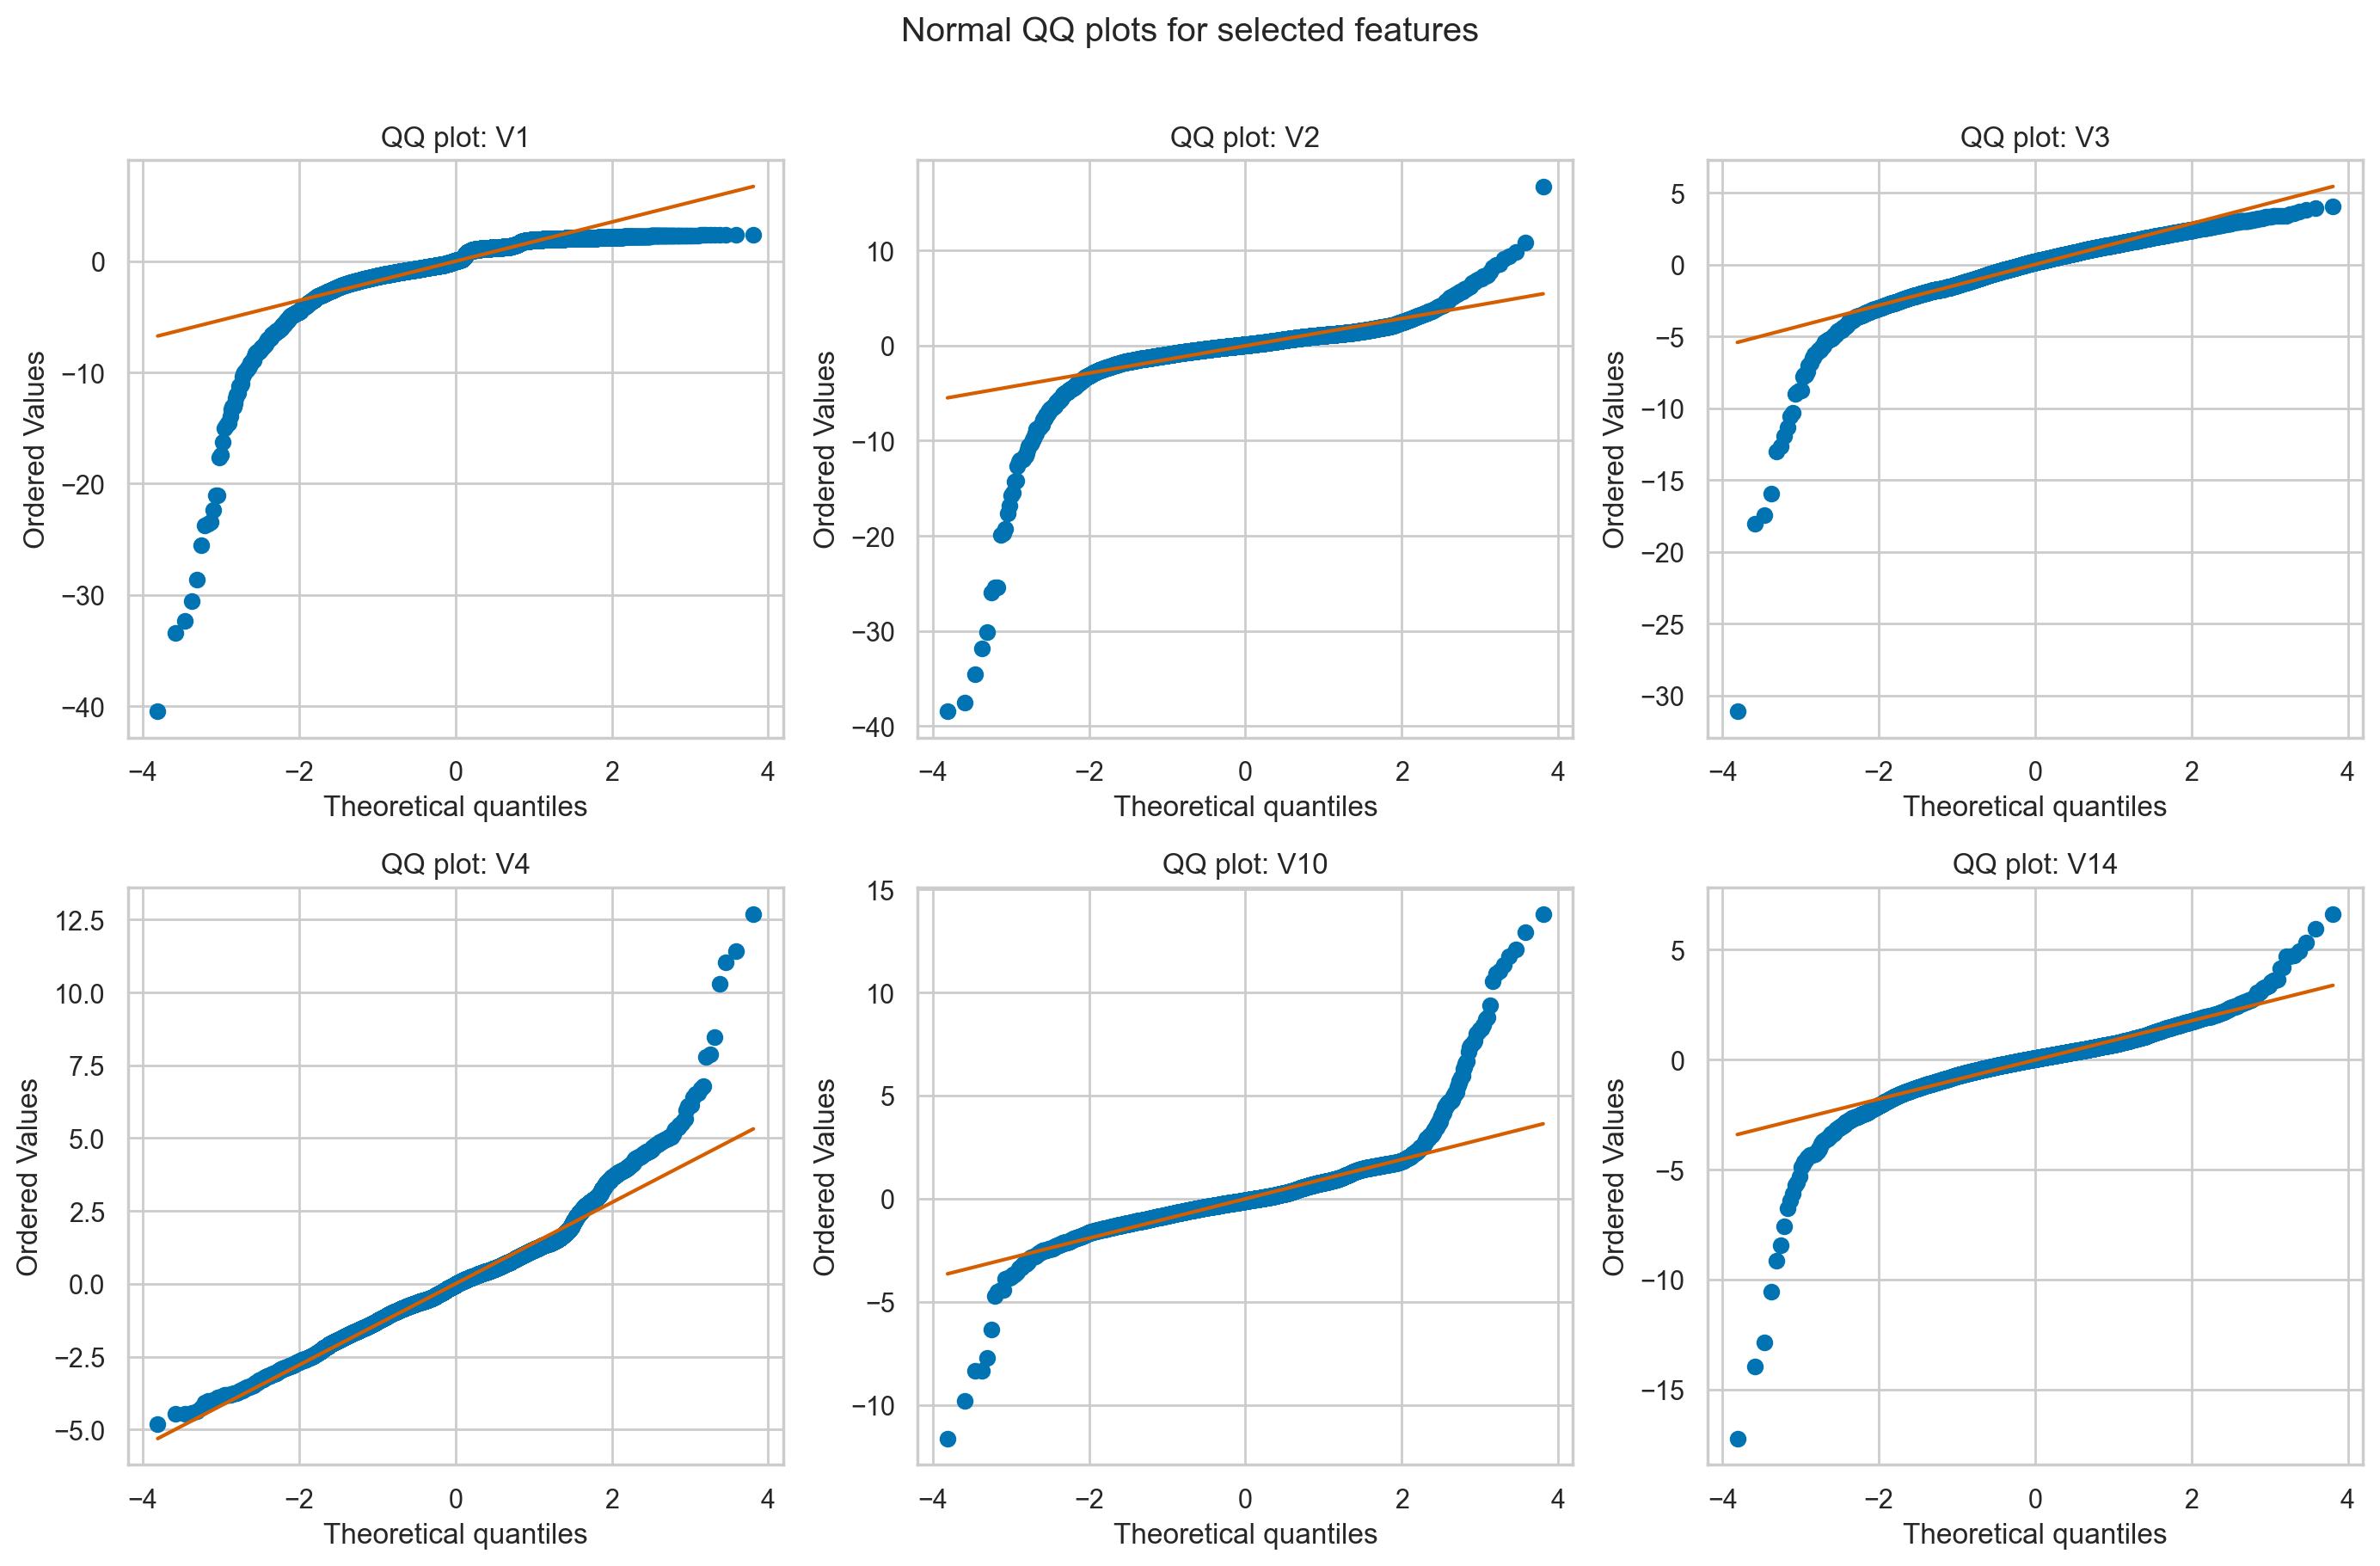

In [13]:
display(Image(
    filename=str(
        FIGURE_DIR / 'phase1_feature_qqplots.png'
    )
))

## Scatter-Plot Matrix

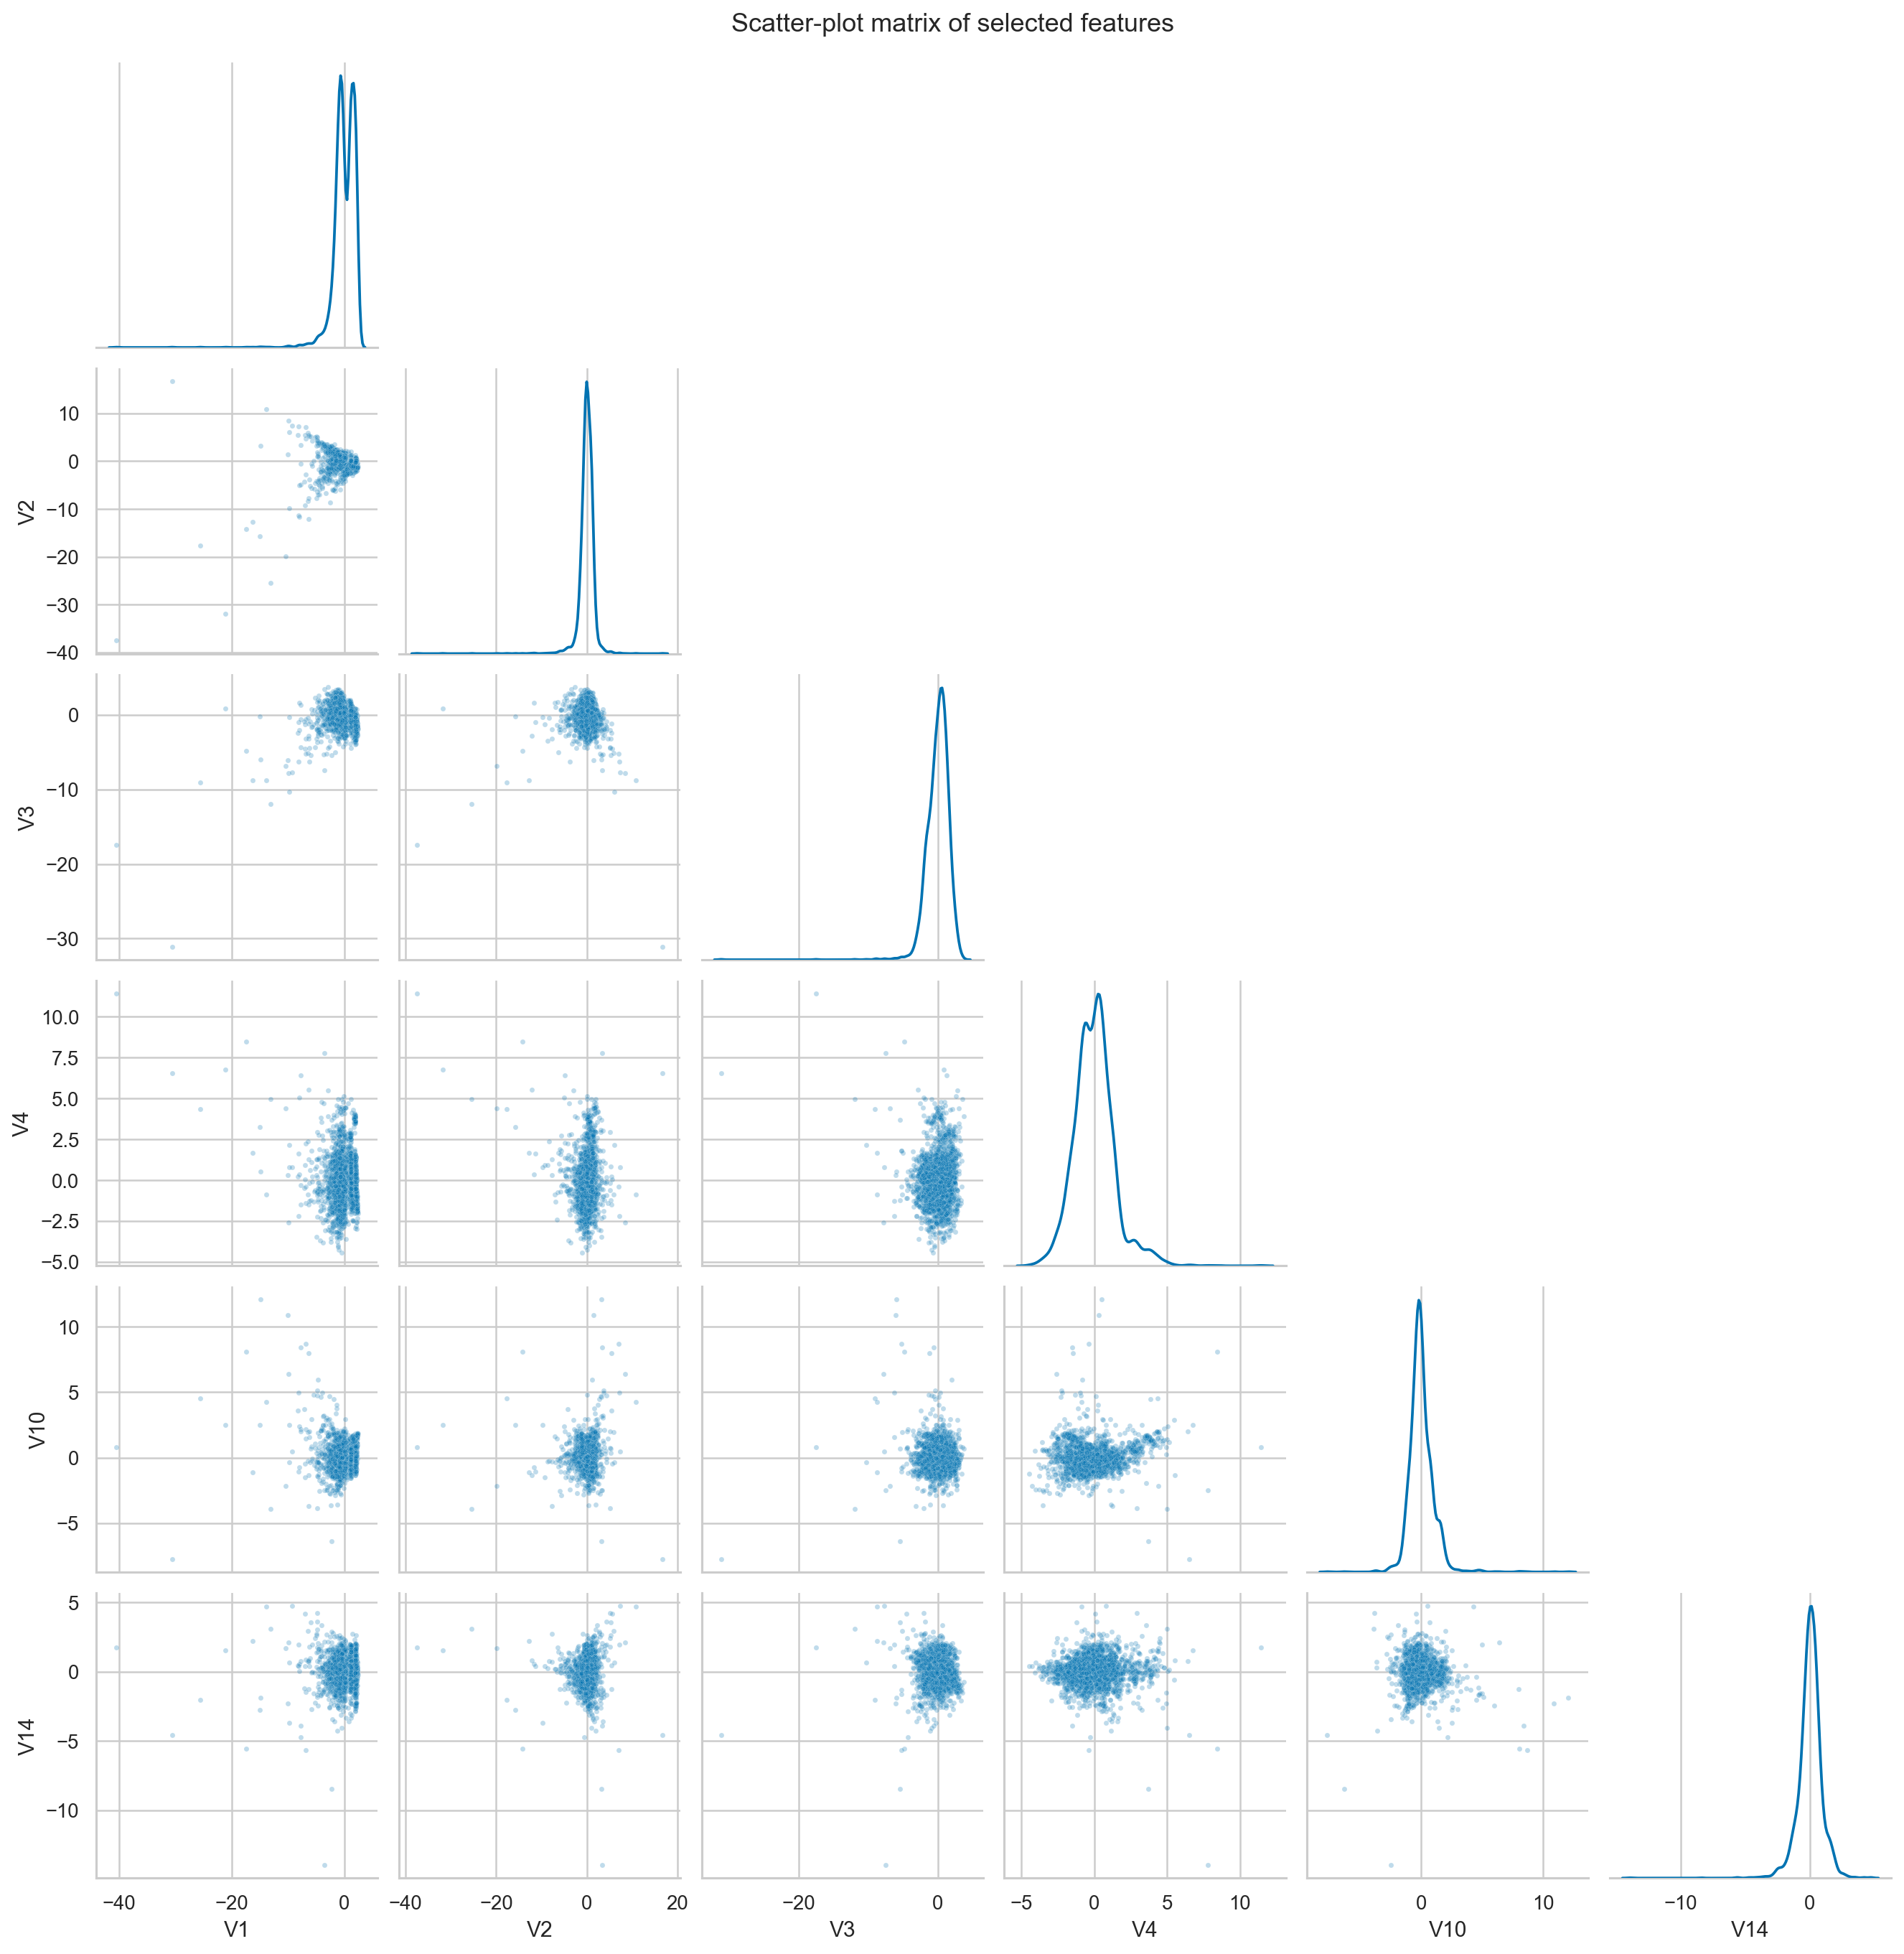

In [14]:
display(Image(
    filename=str(
        FIGURE_DIR / 'phase1_feature_pairplot.png'
    )
))

## Significance-Masked Correlation

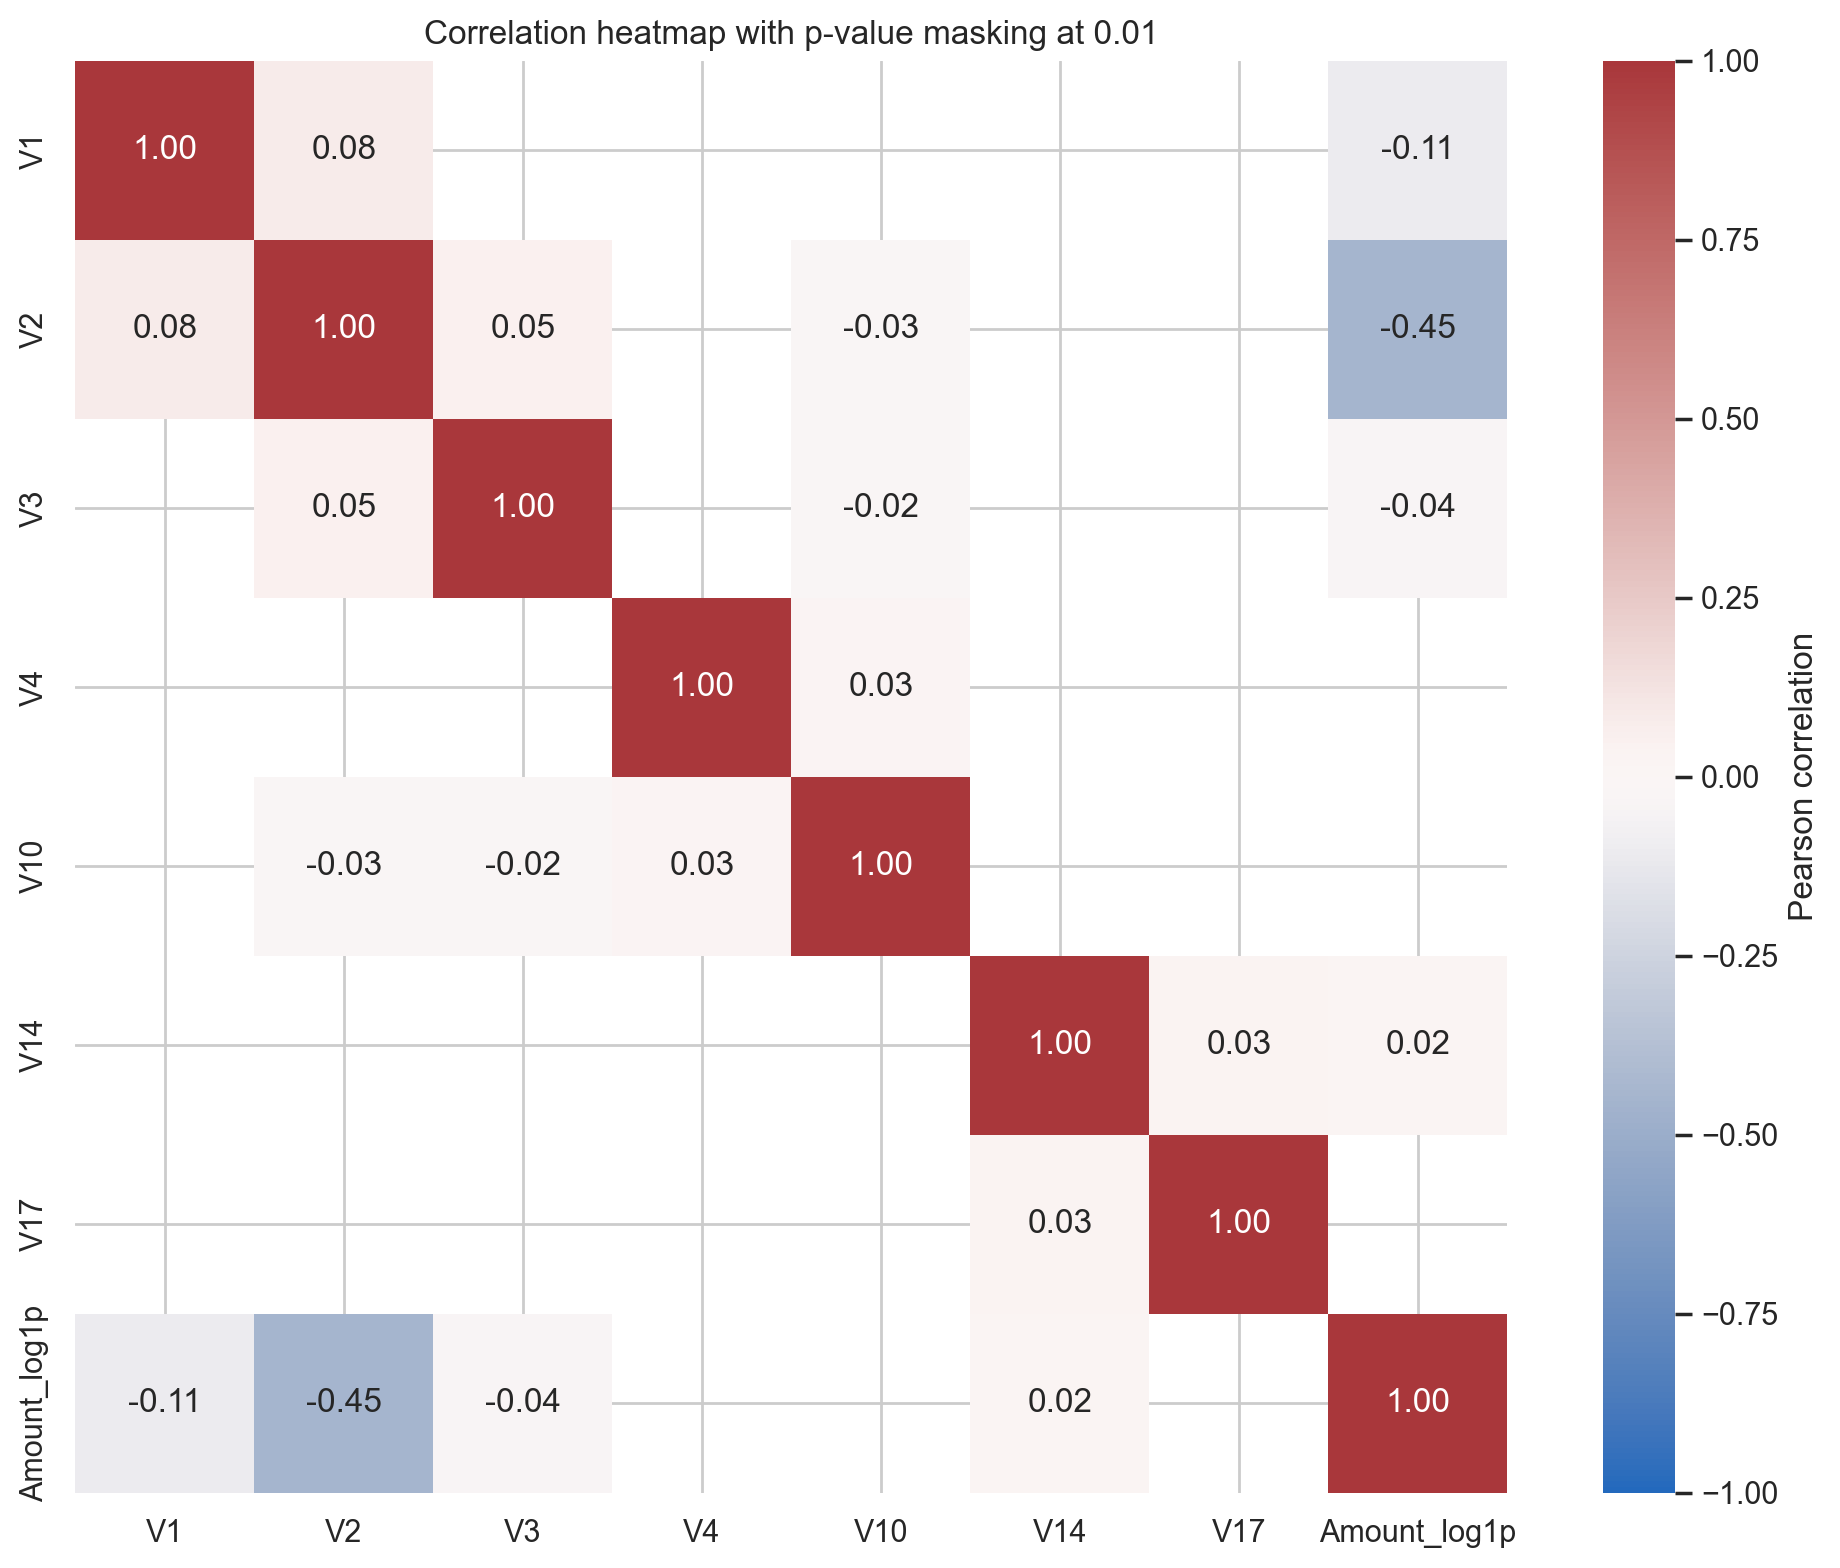

In [15]:
display(Image(
    filename=str(
        FIGURE_DIR / 'phase1_significance_masked_correlation.png'
    )
))

## Phase 1 Deliverables

- Reproducible ingestion and preprocessing
- Cleaning decision log
- Feature engineering
- Standard and robust scaling comparison
- PCA and UMAP
- Hopkins clustering tendency
- MST-based VAT
- Clustering-oriented EDA
- PDF report